In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from scipy.ndimage import rotate
import numpy as np

# -----------------------------
# Parameters
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_images = 1         # number of slices per sample
crop = 128
image_size = 128
batch_size = 16
epochs = 200

lr_G = 2e-4
lr_D = 1e-4
beta1 = 0.5
lambda_L1 = 100.0

In [30]:
type(np.array([]))

numpy.ndarray

In [3]:
# -----------------------------
# Forward Projection
# -----------------------------
angles = np.linspace(0, 180, image_size, endpoint=False)

def compute_sinogram(img_tensor):
    if(type(img_tensor) != type(np.array([]))):
        img = img_tensor[0].numpy()
    else:
        img = img_tensor[0]
    sino = []
    for theta in angles:
        rotated = rotate(img, theta, reshape=False, order=1)
        projection = np.sum(rotated, axis=0)
        sino.append(projection)
    return torch.tensor(np.array(sino)).unsqueeze(0)  # (1, H, W)

In [4]:
# -----------------------------
# Transform
# -----------------------------
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(crop),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


In [5]:
# -----------------------------
# Load PET dataset
# -----------------------------
pet_base_ds = ImageFolder("D:/New folder/DatasetX/", transform=transform)

In [6]:
# -----------------------------
# Precompute sinograms
# -----------------------------
precomputed_sinos = []
for i in range(len(pet_base_ds)):
    img, _ = pet_base_ds[i]
    sino = compute_sinogram(img)
    precomputed_sinos.append(sino)
precomputed_sinos = torch.stack(precomputed_sinos)  # (N, 1, H, W)

In [31]:
def center_crop_tensor(x, crop_size):
    """
    x: tensor (..., H, W)
    crop_size: int
    """
    _, H, W = x.shape
    top = (H - crop_size) // 2
    left = (W - crop_size) // 2
    return x[:, top:top + crop_size, left:left + crop_size]
# -----------------------------
# Multi-Slice Dataset
# -----------------------------
class MultiSliceDataset(Dataset):
    def __init__(self, pet_dataset, sinos_tensor, num_slices, crop_size=180):
        self.pet_ds = pet_dataset
        self.sinos = sinos_tensor
        self.num_slices = num_slices
        self.crop_size = crop_size

    def __len__(self):
        return len(self.pet_ds) - self.num_slices + 1

    def __getitem__(self, idx):
        # ---------------------
        # PET slices (already transformed)
        # ---------------------
        pet_slices = [self.pet_ds[idx + i][0] for i in range(self.num_slices)]
        pet_stack = torch.cat(pet_slices, dim=0)  # (num_slices, H, W)

        # ---------------------
        # Sinogram slices (crop here)
        # ---------------------
        sino_slices = []
        for i in range(self.num_slices):
            sino = self.sinos[idx + i]          # (1, 256, 256)
            sino = center_crop_tensor(sino, self.crop_size)  # (1, 180, 180)
            sino_slices.append(sino)

        sino_stack = torch.cat(sino_slices, dim=0)  # (num_slices, 180, 180)

        return pet_stack, sino_stack

dataset = MultiSliceDataset(
    pet_base_ds,
    precomputed_sinos,
    num_images,
    crop_size=crop
)

train_dl = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [32]:
class AxialAttention(nn.Module):
    def __init__(self, in_channels, heads=4, dim_head=None):
        super().__init__()

        self.heads = heads
        self.dim_head = dim_head or (in_channels // heads)
        self.inner_dim = self.heads * self.dim_head

        assert in_channels % heads == 0, "in_channels must be divisible by heads"

        # Shared projections
        self.to_qkv = nn.Conv2d(
            in_channels,
            self.inner_dim * 3,
            kernel_size=1,
            bias=False
        )

        self.out = nn.Conv2d(self.inner_dim, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.shape

        qkv = self.to_qkv(x)
        q, k, v = qkv.chunk(3, dim=1)

        # reshape to (B, heads, dim_head, H, W)
        q = q.view(B, self.heads, self.dim_head, H, W)
        k = k.view(B, self.heads, self.dim_head, H, W)
        v = v.view(B, self.heads, self.dim_head, H, W)

        # ----- Height attention -----
        q_h = q.permute(0, 1, 4, 2, 3)   # (B, heads, W, dim, H)
        k_h = k.permute(0, 1, 4, 2, 3)
        v_h = v.permute(0, 1, 4, 2, 3)

        attn_h = torch.matmul(
            q_h.transpose(-2, -1),
            k_h
        ) / (self.dim_head ** 0.5)

        attn_h = F.softmax(attn_h, dim=-1)

        out_h = torch.matmul(attn_h, v_h.transpose(-2, -1))
        out_h = out_h.transpose(-2, -1)

        # ----- Width attention -----
        q_w = q.permute(0, 1, 3, 2, 4)   # (B, heads, H, dim, W)
        k_w = k.permute(0, 1, 3, 2, 4)
        v_w = v.permute(0, 1, 3, 2, 4)

        attn_w = torch.matmul(
            q_w.transpose(-2, -1),
            k_w
        ) / (self.dim_head ** 0.5)

        attn_w = F.softmax(attn_w, dim=-1)

        out_w = torch.matmul(attn_w, v_w.transpose(-2, -1))
        out_w = out_w.transpose(-2, -1)

        # combine
        out = out_h.permute(0, 1, 3, 4, 2) + \
              out_w.permute(0, 1, 3, 4, 2)

        out = out.reshape(B, self.inner_dim, H, W)
        out = self.out(out)

        return self.gamma * out + x


In [33]:
# -----------------------------
# Generator
# -----------------------------
class PETGenerator(nn.Module):
    def __init__(self, in_ch=num_images, ngf=64):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(in_ch, ngf, 4, 2, 1),
            nn.ReLU(True),
            AxialAttention(ngf),

            nn.Conv2d(ngf, ngf*2, 4, 2, 1),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),
            AxialAttention(ngf*2),

            nn.Conv2d(ngf*2, ngf*4, 4, 2, 1),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),
            AxialAttention(ngf*4),
        )


        self.dec = nn.Sequential(

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(ngf*4, ngf*2, 3, 1, 1),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(ngf*2, ngf, 3, 1, 1),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(ngf, in_ch, 3, 1, 1),
            nn.Tanh()
        )


    def forward(self, x):
        z = self.enc(x)
        return self.dec(z)

In [34]:
# -----------------------------
# Discriminator
# -----------------------------
class PETDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # nn.Conv2d(num_images * 2, 64, 4, 2, 1),
            # nn.LeakyReLU(0.2, inplace=True),

            # nn.Conv2d(64, 128, 4, 2, 1),
            # nn.BatchNorm2d(128),
            # nn.LeakyReLU(0.2, inplace=True),

            # nn.Conv2d(128, 256, 4, 2, 1),
            # nn.BatchNorm2d(256),
            # nn.LeakyReLU(0.2, inplace=True),

            # nn.Conv2d(256, 1, 4, 1, 0)
            nn.Conv2d(num_images * 2, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            #nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            #nn.BatchNorm2d(512),
            #nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.AdaptiveAvgPool2d(2),   # forces 1x1 spatial output
            nn.Flatten(),
            #nn.Sigmoid()
        )

    def forward(self, sino, pet):
        #print(sino.shape,pet.shape)
        x = torch.cat([sino, pet], dim=1)
        return self.model(x)

In [35]:
# -----------------------------
# Initialize models and optimizers
# -----------------------------
G = PETGenerator().to(device)
D = PETDiscriminator().to(device)

adversarial_loss = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(G.parameters(), lr=lr_G, betas=(beta1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr_D, betas=(beta1, 0.999))

[Epoch 1/200] D_loss: 0.7233 | G_loss: 2.0642


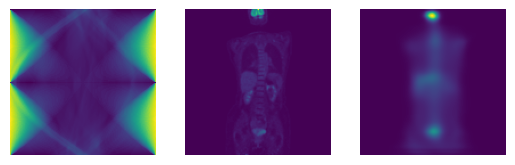

[Epoch 2/200] D_loss: 0.6679 | G_loss: 1.7308


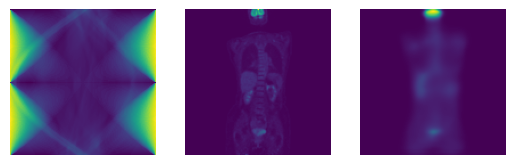

[Epoch 3/200] D_loss: 0.6600 | G_loss: 1.7277


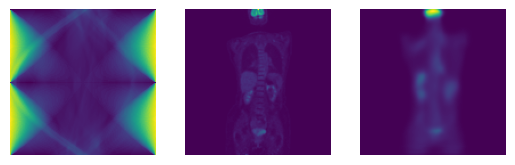

[Epoch 4/200] D_loss: 0.6674 | G_loss: 1.7339


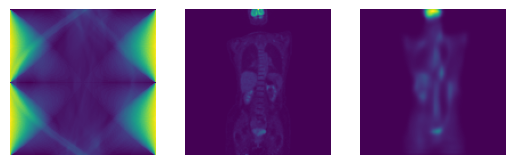

[Epoch 5/200] D_loss: 0.7134 | G_loss: 1.8149


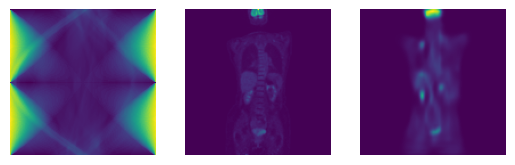

[Epoch 6/200] D_loss: 0.6715 | G_loss: 1.7396


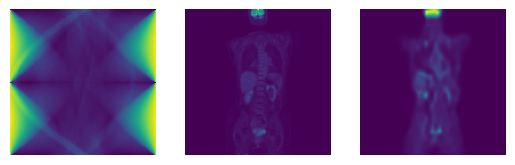

[Epoch 7/200] D_loss: 0.6803 | G_loss: 1.8178


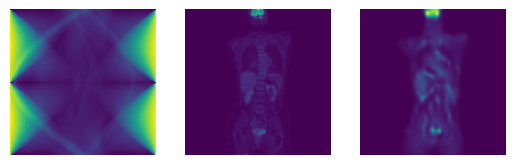

[Epoch 8/200] D_loss: 0.6762 | G_loss: 1.7349


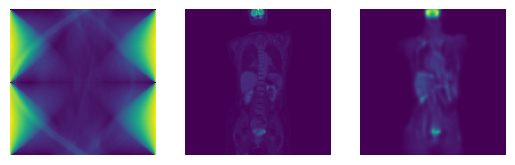

[Epoch 9/200] D_loss: 0.6852 | G_loss: 1.7473


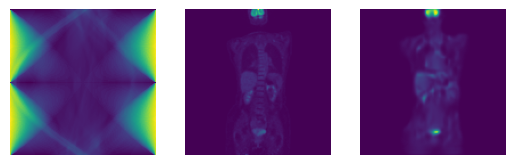

[Epoch 10/200] D_loss: 0.7040 | G_loss: 1.8270


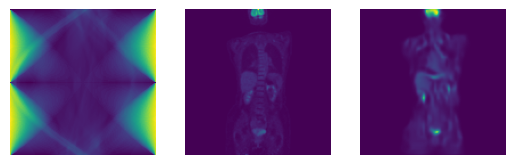

[Epoch 11/200] D_loss: 0.7286 | G_loss: 1.8303


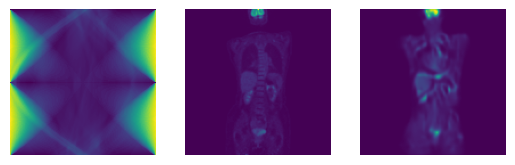

[Epoch 12/200] D_loss: 0.6946 | G_loss: 1.7645


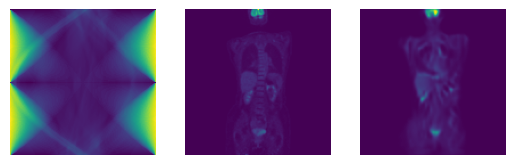

[Epoch 13/200] D_loss: 0.6859 | G_loss: 1.8274


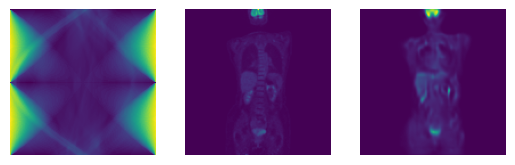

[Epoch 14/200] D_loss: 0.6865 | G_loss: 1.8109


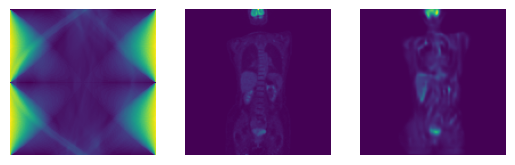

[Epoch 15/200] D_loss: 0.6579 | G_loss: 1.8533


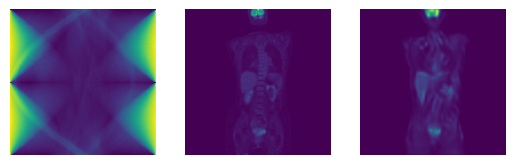

[Epoch 16/200] D_loss: 0.7179 | G_loss: 1.8845


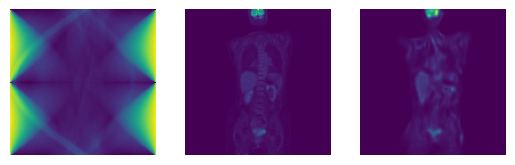

[Epoch 17/200] D_loss: 0.6959 | G_loss: 1.8495


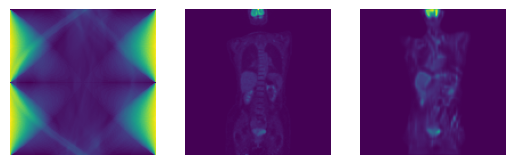

[Epoch 18/200] D_loss: 0.6361 | G_loss: 1.7758


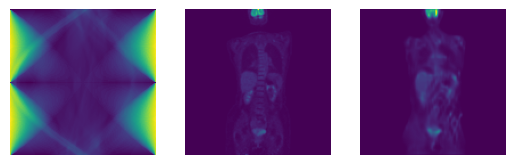

[Epoch 19/200] D_loss: 0.6837 | G_loss: 1.7962


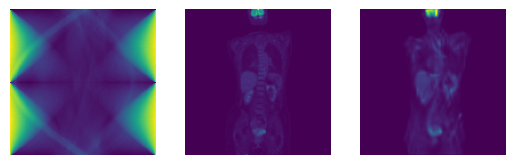

[Epoch 20/200] D_loss: 0.6942 | G_loss: 1.8561


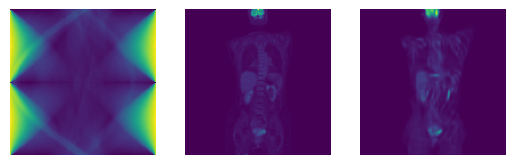

[Epoch 21/200] D_loss: 0.6712 | G_loss: 1.8857


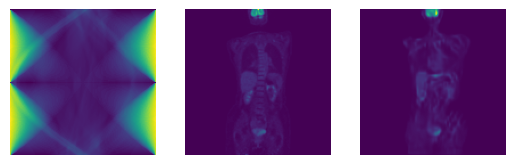

[Epoch 22/200] D_loss: 0.6547 | G_loss: 2.0000


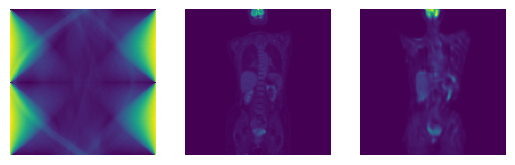

[Epoch 23/200] D_loss: 0.6197 | G_loss: 2.1368


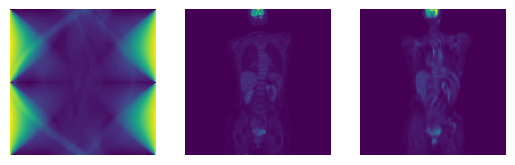

[Epoch 24/200] D_loss: 0.6317 | G_loss: 2.4678


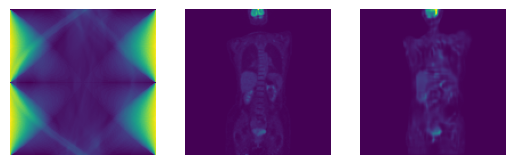

[Epoch 25/200] D_loss: 0.6208 | G_loss: 2.4090


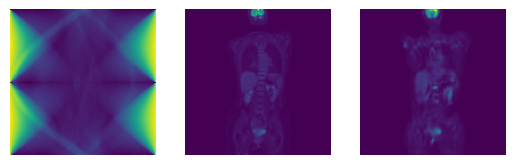

[Epoch 26/200] D_loss: 0.5944 | G_loss: 2.3722


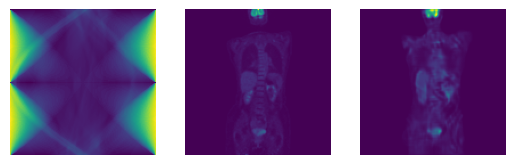

[Epoch 27/200] D_loss: 0.6456 | G_loss: 2.5504


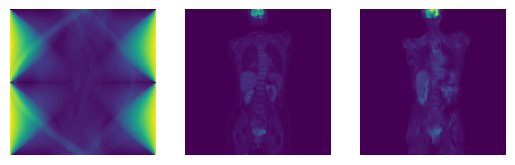

[Epoch 28/200] D_loss: 0.5929 | G_loss: 2.0296


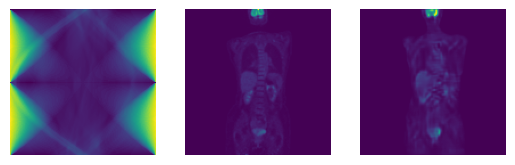

[Epoch 29/200] D_loss: 0.5968 | G_loss: 2.3461


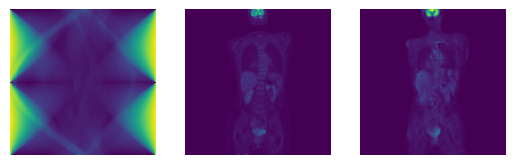

[Epoch 30/200] D_loss: 0.5953 | G_loss: 2.2737


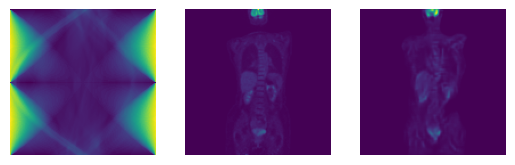

[Epoch 31/200] D_loss: 0.5634 | G_loss: 2.4258


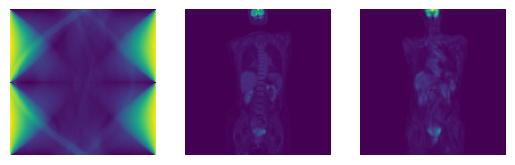

[Epoch 32/200] D_loss: 0.6074 | G_loss: 2.4560


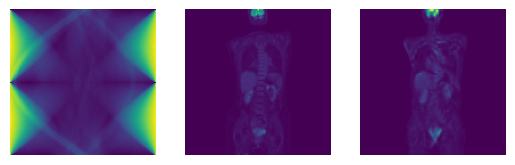

[Epoch 33/200] D_loss: 0.5872 | G_loss: 2.1938


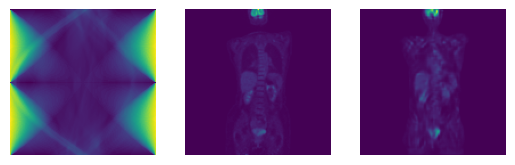

[Epoch 34/200] D_loss: 0.5660 | G_loss: 2.0768


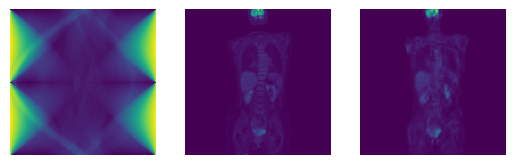

[Epoch 35/200] D_loss: 0.5838 | G_loss: 2.4622


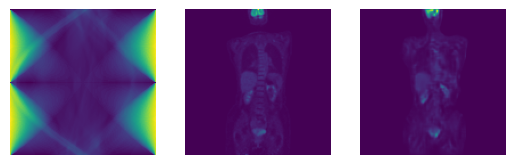

[Epoch 36/200] D_loss: 0.5505 | G_loss: 2.1110


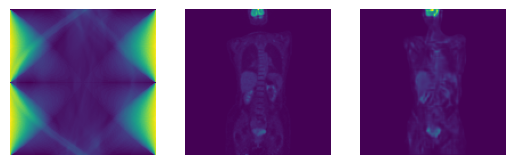

[Epoch 37/200] D_loss: 0.5506 | G_loss: 2.4656


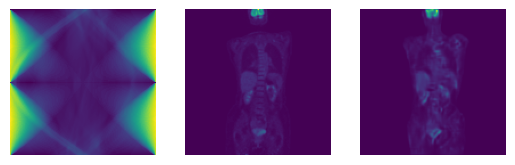

[Epoch 38/200] D_loss: 0.6052 | G_loss: 1.8552


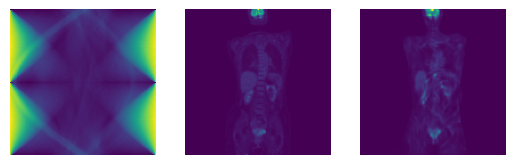

[Epoch 39/200] D_loss: 0.6066 | G_loss: 3.1389


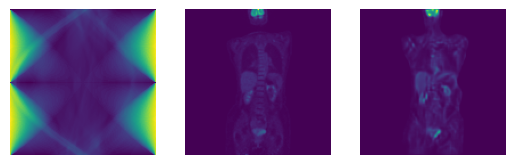

[Epoch 40/200] D_loss: 0.5301 | G_loss: 2.4351


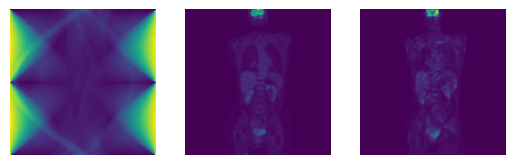

[Epoch 41/200] D_loss: 0.5395 | G_loss: 3.1458


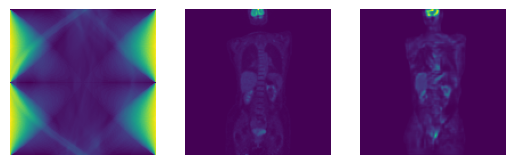

[Epoch 42/200] D_loss: 0.5289 | G_loss: 3.1773


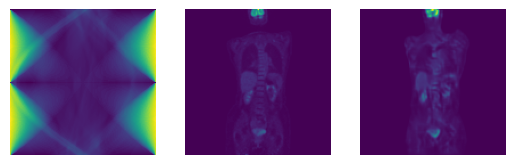

[Epoch 43/200] D_loss: 0.5391 | G_loss: 2.8428


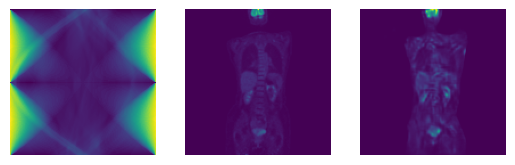

[Epoch 44/200] D_loss: 0.5123 | G_loss: 2.9741


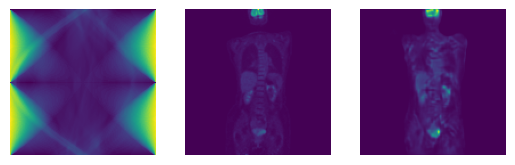

[Epoch 45/200] D_loss: 0.5509 | G_loss: 2.5089


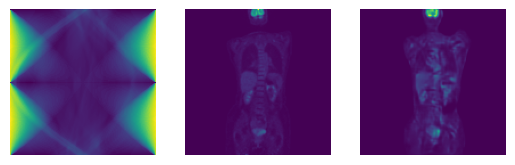

[Epoch 46/200] D_loss: 0.5283 | G_loss: 2.7392


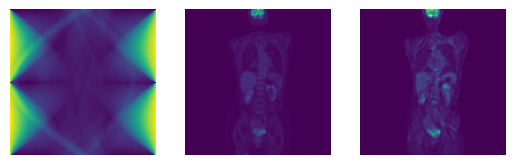

[Epoch 47/200] D_loss: 0.4947 | G_loss: 2.8041


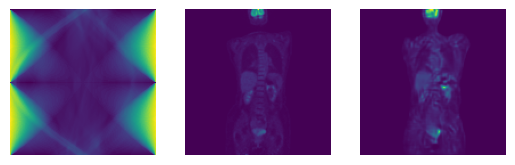

[Epoch 48/200] D_loss: 0.4813 | G_loss: 3.1904


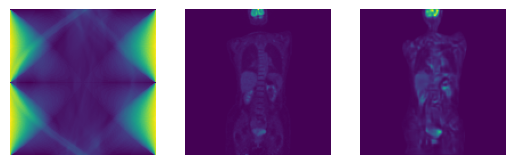

[Epoch 49/200] D_loss: 0.4756 | G_loss: 3.5835


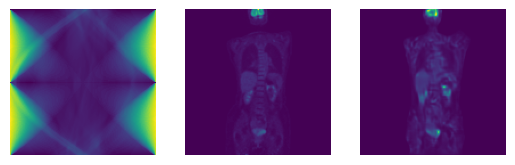

[Epoch 50/200] D_loss: 0.4445 | G_loss: 2.3436


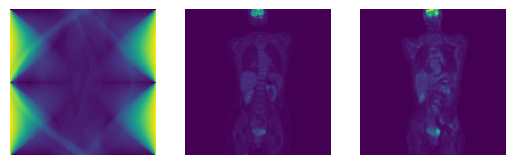

[Epoch 51/200] D_loss: 0.4744 | G_loss: 3.4962


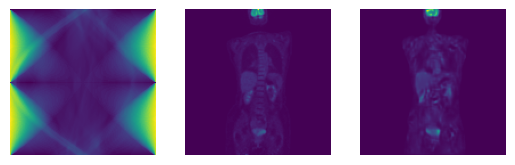

[Epoch 52/200] D_loss: 0.4854 | G_loss: 3.3391


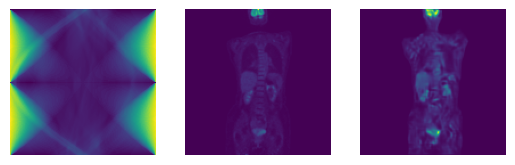

[Epoch 53/200] D_loss: 0.4711 | G_loss: 2.1080


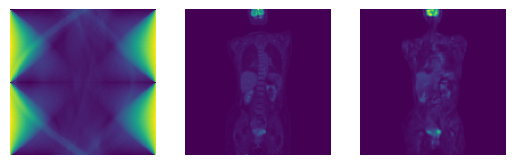

[Epoch 54/200] D_loss: 0.4467 | G_loss: 3.0259


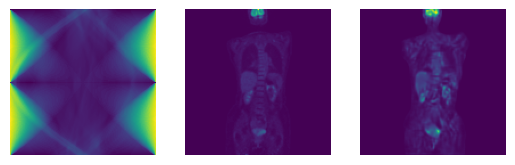

[Epoch 55/200] D_loss: 0.4800 | G_loss: 3.4473


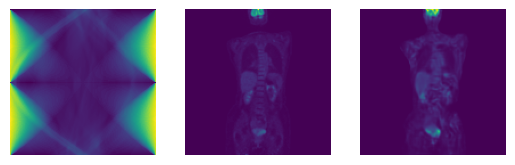

[Epoch 56/200] D_loss: 0.5326 | G_loss: 1.9250


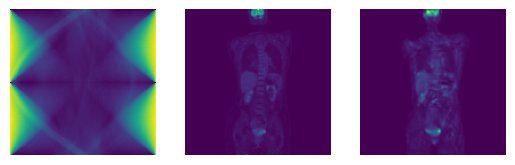

[Epoch 57/200] D_loss: 0.4389 | G_loss: 3.1162


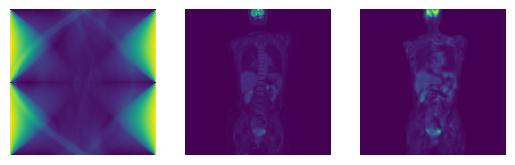

[Epoch 58/200] D_loss: 0.4392 | G_loss: 2.4722


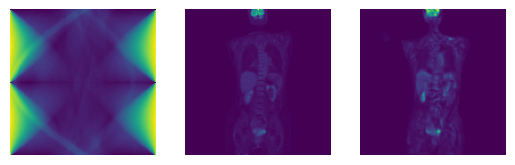

[Epoch 59/200] D_loss: 0.4218 | G_loss: 3.1102


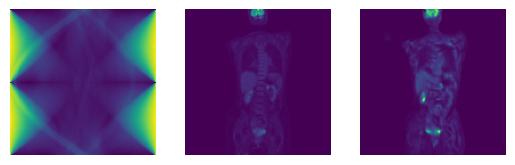

[Epoch 60/200] D_loss: 0.5128 | G_loss: 4.3802


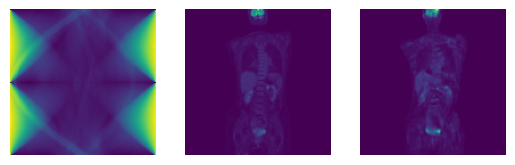

[Epoch 61/200] D_loss: 0.4419 | G_loss: 3.4472


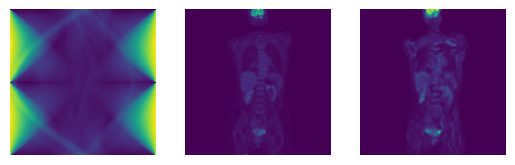

[Epoch 62/200] D_loss: 0.4369 | G_loss: 4.0662


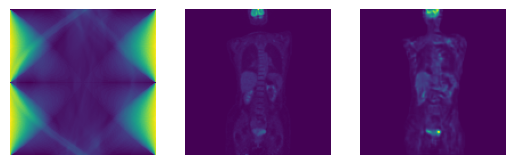

[Epoch 63/200] D_loss: 0.4460 | G_loss: 3.3319


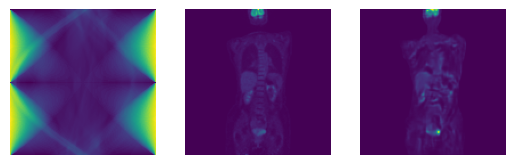

[Epoch 64/200] D_loss: 0.4416 | G_loss: 3.6113


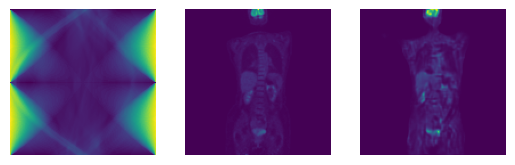

[Epoch 65/200] D_loss: 0.4205 | G_loss: 3.2122


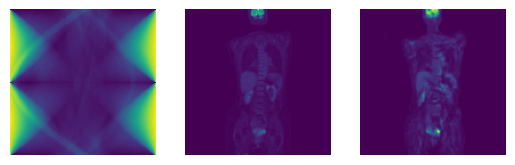

[Epoch 66/200] D_loss: 0.4800 | G_loss: 4.4975


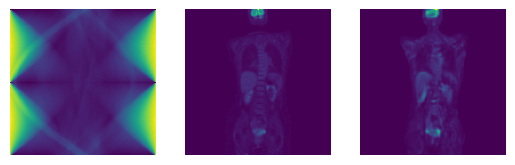

[Epoch 67/200] D_loss: 0.3771 | G_loss: 3.3345


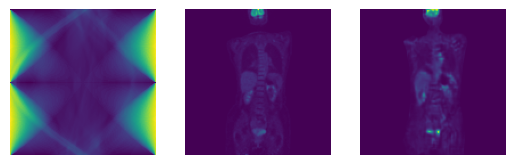

[Epoch 68/200] D_loss: 0.4153 | G_loss: 2.7953


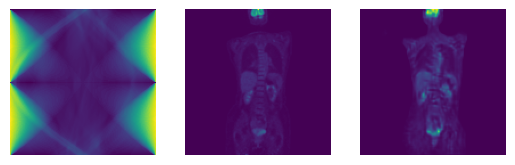

[Epoch 69/200] D_loss: 0.3661 | G_loss: 3.2414


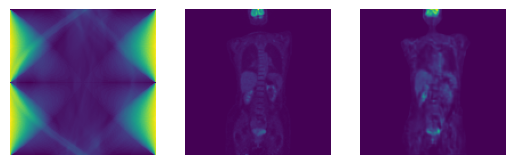

[Epoch 70/200] D_loss: 0.4894 | G_loss: 4.4873


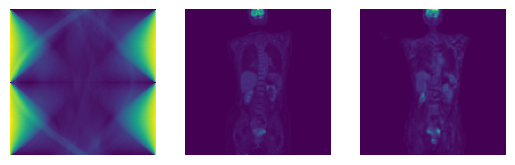

[Epoch 71/200] D_loss: 0.3908 | G_loss: 2.8000


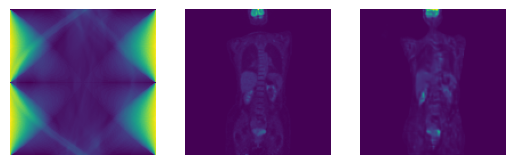

[Epoch 72/200] D_loss: 0.3782 | G_loss: 3.4586


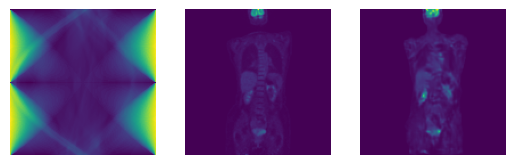

[Epoch 73/200] D_loss: 0.3683 | G_loss: 3.5712


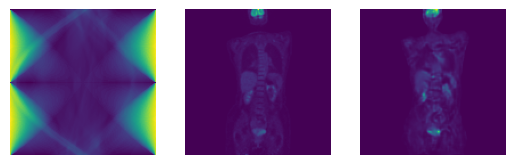

[Epoch 74/200] D_loss: 0.4101 | G_loss: 3.6815


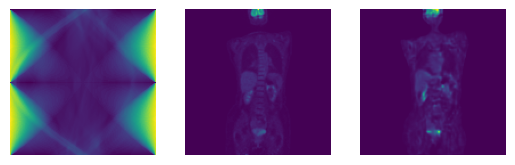

[Epoch 75/200] D_loss: 0.4146 | G_loss: 3.9066


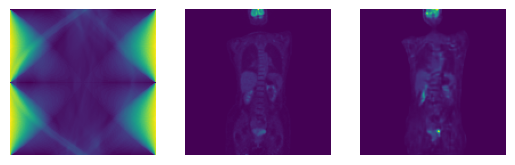

[Epoch 76/200] D_loss: 0.4108 | G_loss: 3.3623


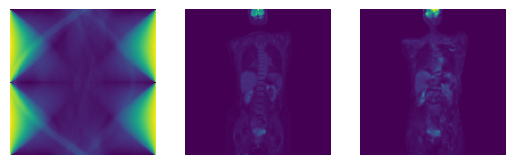

[Epoch 77/200] D_loss: 0.4002 | G_loss: 3.3227


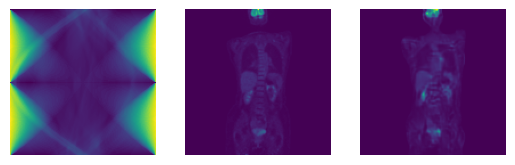

[Epoch 78/200] D_loss: 0.4384 | G_loss: 4.2205


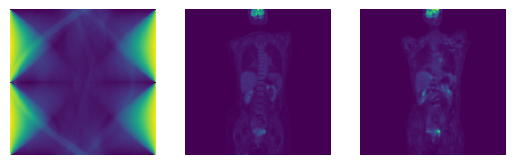

[Epoch 79/200] D_loss: 0.4521 | G_loss: 4.3944


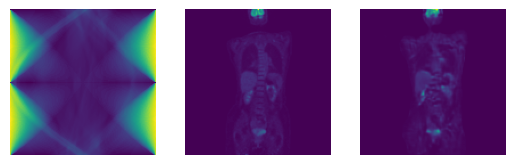

[Epoch 80/200] D_loss: 0.4095 | G_loss: 4.0621


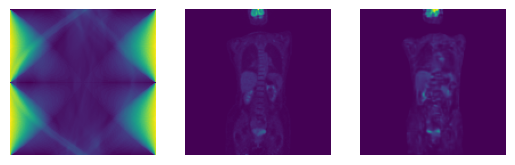

[Epoch 81/200] D_loss: 0.5371 | G_loss: 4.6580


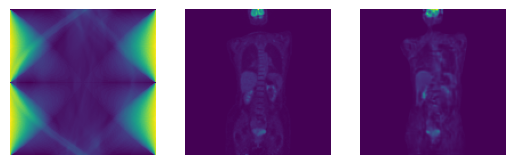

[Epoch 82/200] D_loss: 0.4412 | G_loss: 3.6256


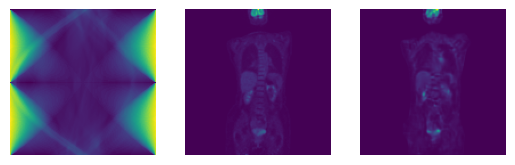

[Epoch 83/200] D_loss: 0.4565 | G_loss: 2.7572


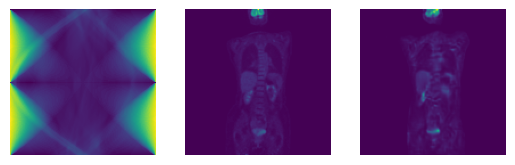

[Epoch 84/200] D_loss: 0.4332 | G_loss: 3.9089


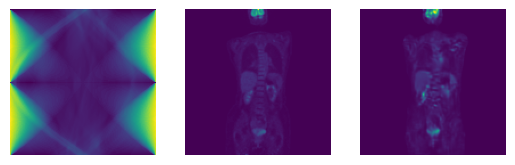

[Epoch 85/200] D_loss: 0.3997 | G_loss: 2.4583


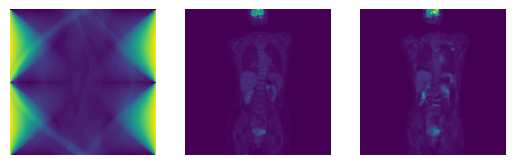

[Epoch 86/200] D_loss: 0.3639 | G_loss: 2.9846


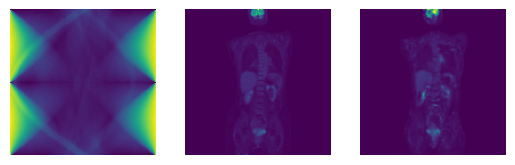

[Epoch 87/200] D_loss: 0.4175 | G_loss: 3.9932


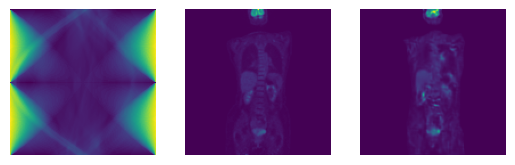

[Epoch 88/200] D_loss: 0.4250 | G_loss: 3.5342


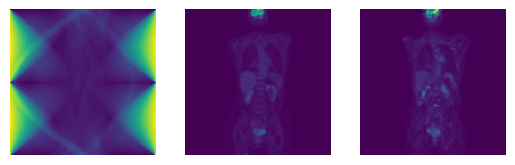

[Epoch 89/200] D_loss: 0.3936 | G_loss: 2.4961


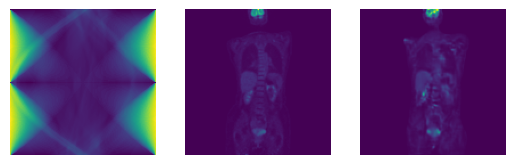

[Epoch 90/200] D_loss: 0.4025 | G_loss: 3.4991


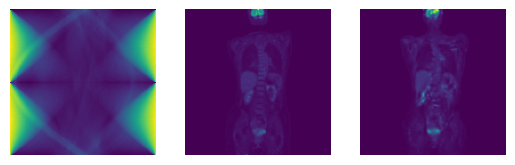

[Epoch 91/200] D_loss: 0.4287 | G_loss: 2.5285


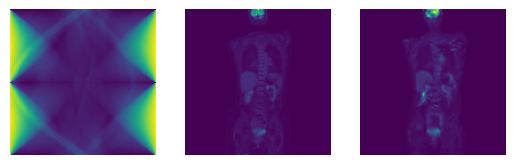

[Epoch 92/200] D_loss: 0.4447 | G_loss: 4.8114


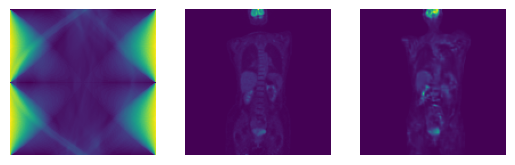

[Epoch 93/200] D_loss: 0.4879 | G_loss: 4.5363


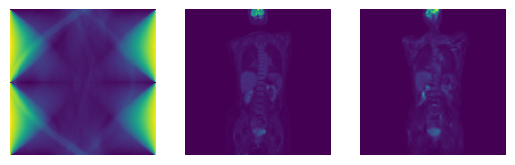

[Epoch 94/200] D_loss: 0.5138 | G_loss: 4.6056


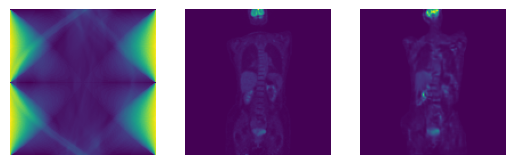

[Epoch 95/200] D_loss: 0.3923 | G_loss: 3.3533


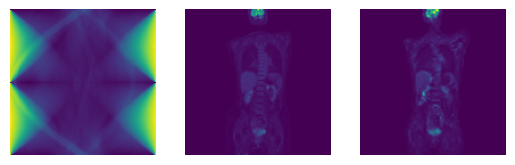

[Epoch 96/200] D_loss: 0.4112 | G_loss: 4.0428


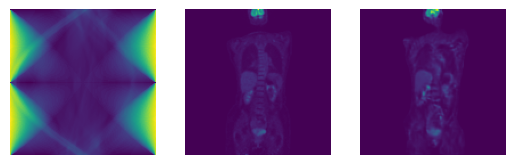

[Epoch 97/200] D_loss: 0.4893 | G_loss: 4.7944


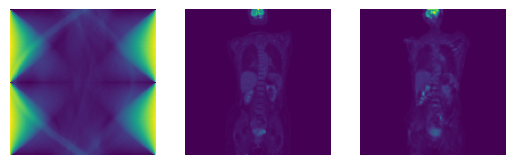

[Epoch 98/200] D_loss: 0.5510 | G_loss: 5.0945


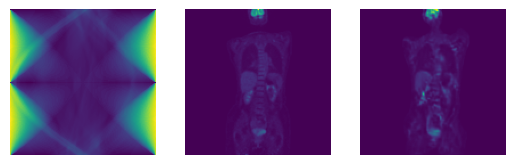

[Epoch 99/200] D_loss: 0.5032 | G_loss: 3.1756


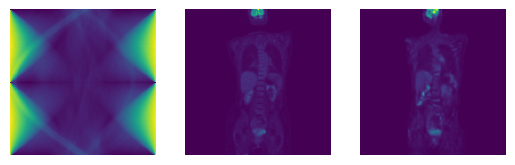

[Epoch 100/200] D_loss: 0.4217 | G_loss: 3.0644


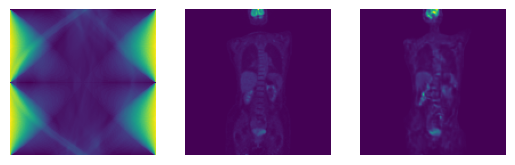

[Epoch 101/200] D_loss: 0.4391 | G_loss: 4.7063


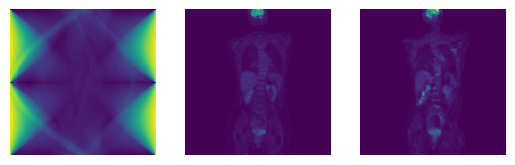

[Epoch 102/200] D_loss: 0.4966 | G_loss: 4.9857


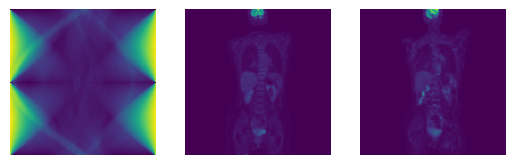

[Epoch 103/200] D_loss: 0.4802 | G_loss: 4.5155


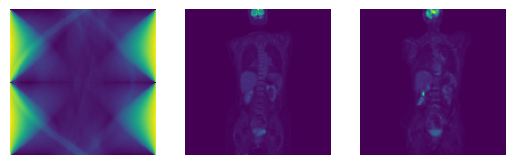

[Epoch 104/200] D_loss: 0.4385 | G_loss: 3.3885


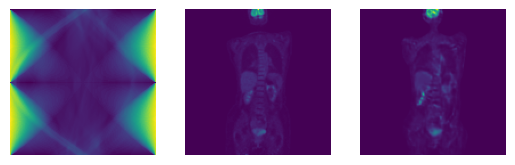

[Epoch 105/200] D_loss: 0.4099 | G_loss: 3.3862


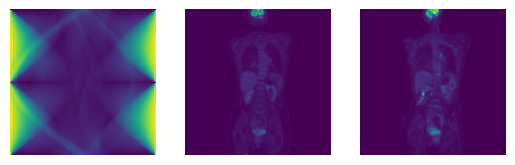

[Epoch 106/200] D_loss: 0.4329 | G_loss: 3.7738


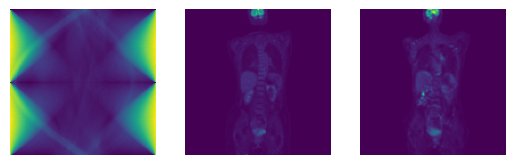

[Epoch 107/200] D_loss: 0.4252 | G_loss: 4.2588


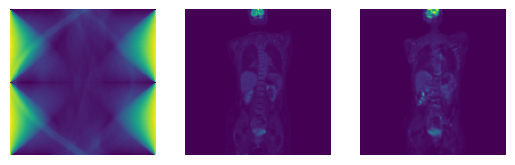

[Epoch 108/200] D_loss: 0.4672 | G_loss: 2.9359


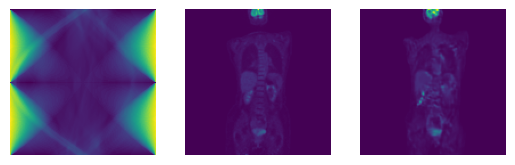

[Epoch 109/200] D_loss: 0.4320 | G_loss: 4.1517


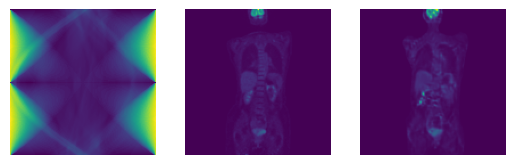

[Epoch 110/200] D_loss: 0.4031 | G_loss: 4.2751


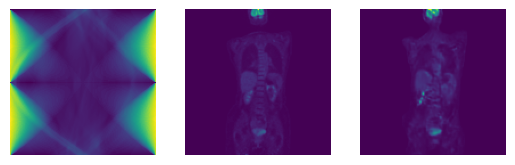

[Epoch 111/200] D_loss: 0.4417 | G_loss: 4.2668


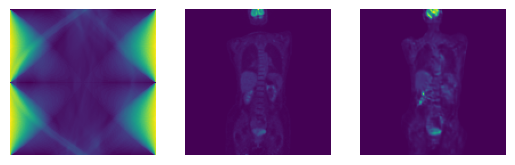

[Epoch 112/200] D_loss: 0.4995 | G_loss: 5.2142


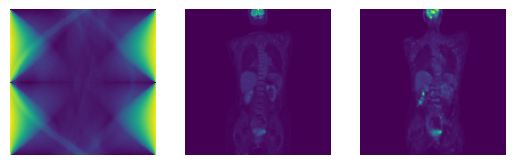

[Epoch 113/200] D_loss: 0.4089 | G_loss: 4.1788


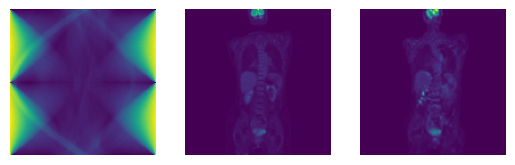

[Epoch 114/200] D_loss: 0.6155 | G_loss: 1.8007


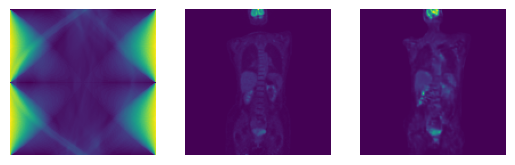

[Epoch 115/200] D_loss: 0.4128 | G_loss: 3.1464


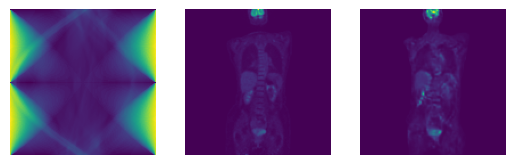

[Epoch 116/200] D_loss: 0.6430 | G_loss: 5.7024


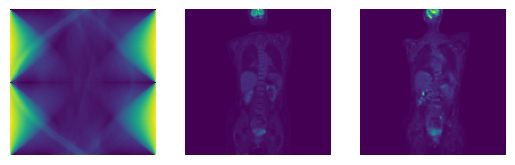

[Epoch 117/200] D_loss: 0.3986 | G_loss: 3.7190


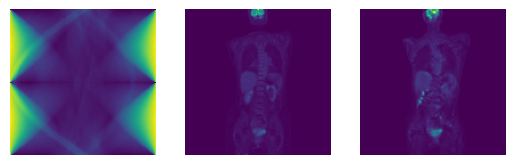

[Epoch 118/200] D_loss: 0.4140 | G_loss: 3.2251


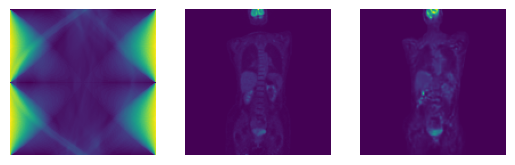

[Epoch 119/200] D_loss: 0.4363 | G_loss: 2.8460


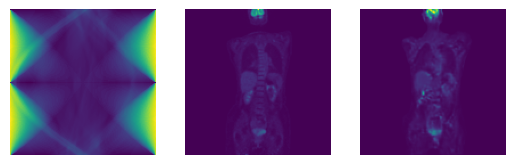

[Epoch 120/200] D_loss: 0.3868 | G_loss: 3.9992


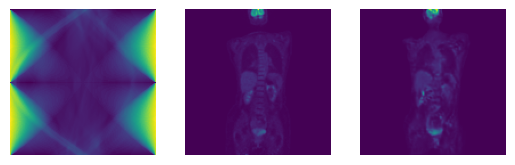

[Epoch 121/200] D_loss: 0.3787 | G_loss: 3.3155


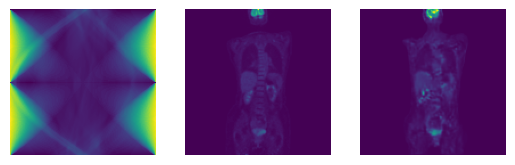

[Epoch 122/200] D_loss: 0.3837 | G_loss: 3.4016


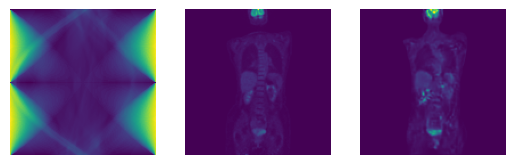

[Epoch 123/200] D_loss: 0.4366 | G_loss: 3.9500


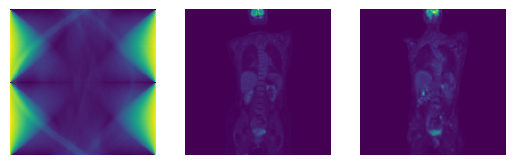

[Epoch 124/200] D_loss: 0.4088 | G_loss: 4.3662


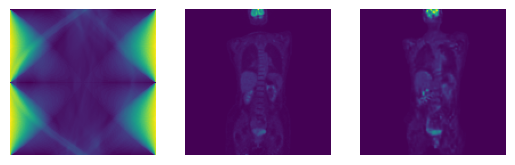

KeyboardInterrupt: 

In [36]:
# -----------------------------
# Training loop
# -----------------------------
import matplotlib.pyplot as plt
for epoch in range(epochs):
    for pet_real, sino_real in train_dl:
        pet_real = pet_real.to(device)
        sino_real = sino_real.to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()
        pet_fake = G(sino_real)

        pred_real = D(sino_real, pet_real)
        pred_fake = D(sino_real, pet_fake.detach())

        valid = torch.full_like(pred_real, 0.9)
        fake  = torch.full_like(pred_fake, 0.1)

        d_loss = (adversarial_loss(pred_real, valid) + adversarial_loss(pred_fake, fake)) / 2
        d_loss.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        optimizer_G.zero_grad()
        adv_loss = adversarial_loss(D(sino_real, pet_fake), torch.ones_like(pred_fake))
        l1_loss = F.l1_loss(pet_fake, pet_real)
        g_loss = adv_loss + lambda_L1 * l1_loss
        g_loss.backward()
        optimizer_G.step()
        

    print(f"[Epoch {epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} | G_loss: {g_loss.item():.4f}")
    fig, (ax1, ax2,ax3) = plt.subplots(1, 3)
    ax1.set_axis_off()
    ax2.set_axis_off()
    ax3.set_axis_off()
    ax1.imshow(sino_real.cpu().detach().numpy()[0][0].reshape(crop,crop))
    ax2.imshow(pet_real.cpu().detach().numpy()[0][0].reshape(crop,crop))
    ax3.imshow(pet_fake.cpu().detach().numpy()[0][0].reshape(crop,crop))
    plt.show()

print("Training complete!")

In [37]:
torch.save(G.state_dict(), 'GanReconstructionModels/GeneratorModel.pth')

In [14]:
print(sino_real.cpu().detach().numpy().shape)

(2, 1, 128, 128)


In [15]:
import matplotlib.pyplot as plt
import numpy as np

import os
import pydicom as dicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
import numpy as np
import cv2

import cv2
image = []
sinograms = []

# -----------------------------
# Transform
# -----------------------------
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(crop),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
Pet_Test = ImageFolder("D:/New folder/TestDatasetFullImages/", transform=transform)
for i in range(400,500):
    #Dir = r'D:\New folder\TestDatasetFullImages/Test/'+os.listdir(r'D:\New folder\TestDatasetFullImages/Test/')[i]
    #print(Dir)
    im,_ = Pet_Test[i]#cv2.imread(Dir,cv2.IMREAD_GRAYSCALE)
    
    sino = compute_sinogram((im))
    image.append(im)
    sinograms.append(sino)




In [16]:
sinograms_p = torch.stack(sinograms)
GeneratedImages = []
dataset = MultiSliceDataset(
    Pet_Test,
    sinograms_p,
    num_images,
    crop_size=crop
)

train_dl = DataLoader(dataset, batch_size=1, shuffle=False)
counter = 100
for _,i in train_dl:
    
    pred = G(i.to(device))
    GeneratedImages.append(pred.cpu().detach().numpy()[0][0])
    counter-=1
    if counter == 0:
        break
len(GeneratedImages)

100

(100, 128, 128)


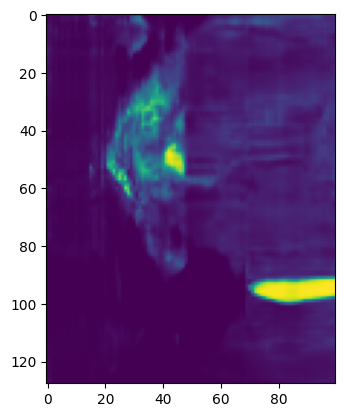

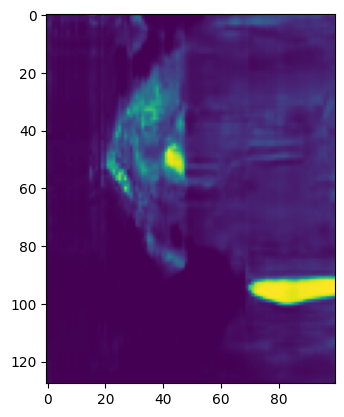

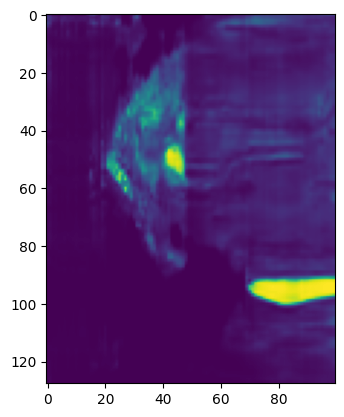

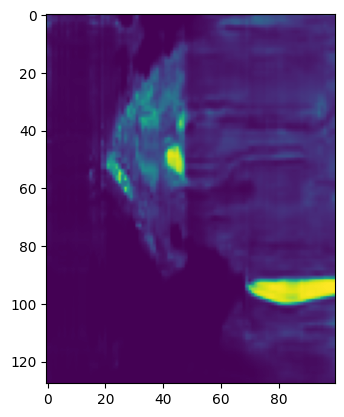

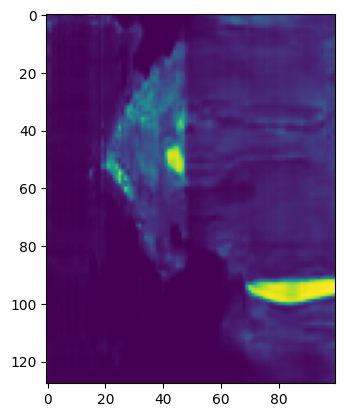

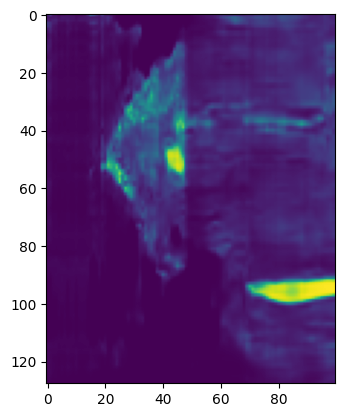

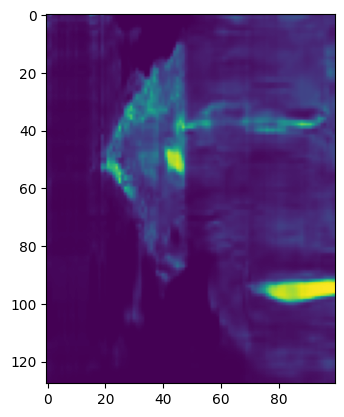

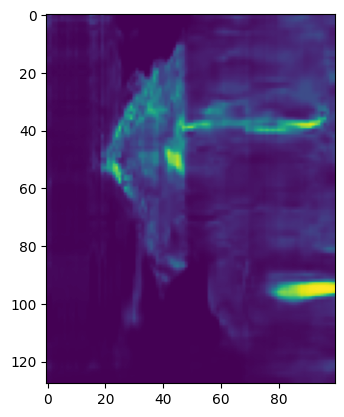

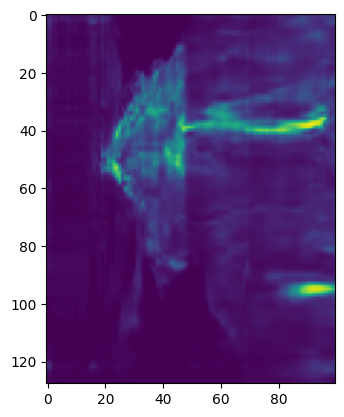

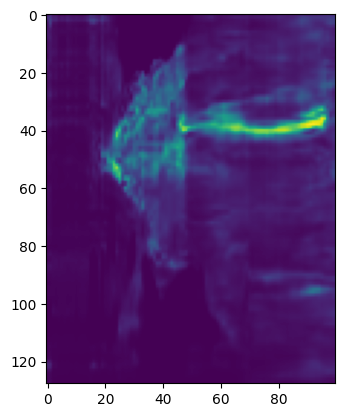

In [17]:
#print(GeneratedImages[4].cpu().detach().numpy().shape)
print(np.asarray(GeneratedImages).shape)
for i in range(0,10):
    plt.imshow(np.asarray(GeneratedImages).T[60+i])
    plt.show()

In [18]:
np.array(image).shape

C:\Users\dorok\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.7_qbz5n2kfra8p0\LocalCache\local-packages\Python37\site-packages\ipykernel_launcher.py:1: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  """Entry point for launching an IPython kernel.
C:\Users\dorok\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.7_qbz5n2kfra8p0\LocalCache\local-packages\Python37\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is de

(100,)

In [19]:
plt.imshow(np.array(image)[:,:,150])


C:\Users\dorok\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.7_qbz5n2kfra8p0\LocalCache\local-packages\Python37\site-packages\ipykernel_launcher.py:1: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  """Entry point for launching an IPython kernel.
C:\Users\dorok\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.7_qbz5n2kfra8p0\LocalCache\local-packages\Python37\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is de

IndexError: too many indices for array: array is 1-dimensional, but 3 were indexed

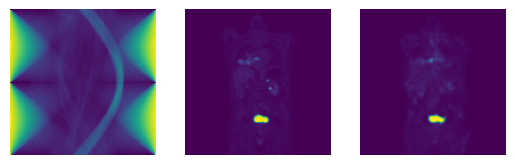

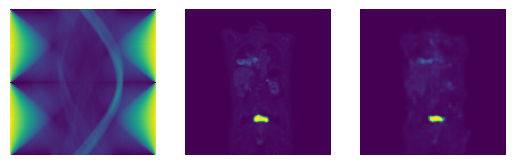

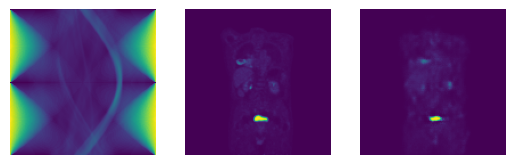

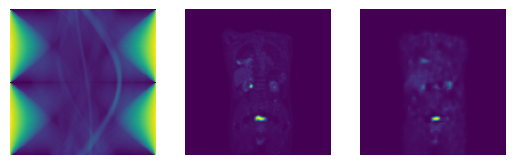

In [ ]:
for i in range(0,16,4):
    #print(f"[Epoch {epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} | G_loss: {g_loss.item():.4f}")
    fig, (ax1, ax2,ax3) = plt.subplots(1, 3)
    ax1.set_axis_off()
    ax2.set_axis_off()
    ax3.set_axis_off()
    ax1.imshow(sino_real.cpu().detach().numpy()[i][0].reshape(crop,crop))
    ax2.imshow(pet_real.cpu().detach().numpy()[i][0].reshape(crop,crop))
    ax3.imshow(pet_fake.cpu().detach().numpy()[i][0].reshape(crop,crop))
    plt.show()

In [ ]:

#sino_real = sino_real.to(device)

#pet_real = pet_real.view(batch_size, num_images, 1, crop, crop)
#sino_real = sino_real.view(batch_size, num_images, 1, crop, crop)

# -----------------------------
# Train Discriminator
# -----------------------------
optimizer_D.zero_grad()

pet_fake = G(sino_real)
import matplotlib.pyplot as plt
plt.imshow(sino_real.cpu().detach().numpy()[0][0].reshape(256,256))
plt.show()
plt.imshow(pet_real.cpu().detach().numpy()[0][0].reshape(256,256))
plt.show()
plt.imshow(pet_fake.cpu().detach().numpy()[0][0].reshape(256,256))
plt.show()

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

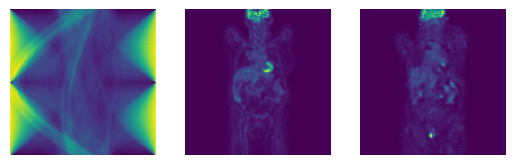

In [ ]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3)
ax1.set_axis_off()
ax2.set_axis_off()
ax3.set_axis_off()
ax1.imshow(sino_real.cpu().detach().numpy()[0][0].reshape(256,256))
ax2.imshow(pet_real.cpu().detach().numpy()[0][0].reshape(256,256))
ax3.imshow(pet_fake.cpu().detach().numpy()[0][0].reshape(256,256))